<a href="https://colab.research.google.com/github/Alaaeldinaly/lesson-image-classification-random-forest/blob/main/image_classification_random_forest_assignment_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification Workflow

## 1) Imports

In [3]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use("ggplot")
sns.set_style("whitegrid")

## 2) Extract the ZIP file


In [4]:
zip_path = "/content/images.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Extracted to:", extract_path)

Dataset extracted successfully.
Extracted to: /content/dataset


## 3) Check Class Folders

In [5]:
data_dir = os.path.join(extract_path, "images")
classes = sorted(os.listdir(data_dir))

print("Classes:")
print(classes)

Classes:
['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']


## 4) Load and Preprocess Images


In [6]:
IMG_SIZE = (64, 64)

X = []
y = []

for class_name in classes:
    class_dir = os.path.join(data_dir, class_name)

    for file_name in os.listdir(class_dir):
        file_path = os.path.join(class_dir, file_name)

        try:
            img = Image.open(file_path).convert("RGB")
            img = img.resize(IMG_SIZE)
            img_array = np.array(img) / 255.0   # normalize
            X.append(img_array.flatten())
            y.append(class_name)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")

X = np.array(X)
y = np.array(y)

print("Images loaded successfully.")
print("X shape:", X.shape)
print("y shape:", y.shape)

Images loaded successfully.
X shape: (309, 12288)
y shape: (309,)


## 5) Display Sample Images

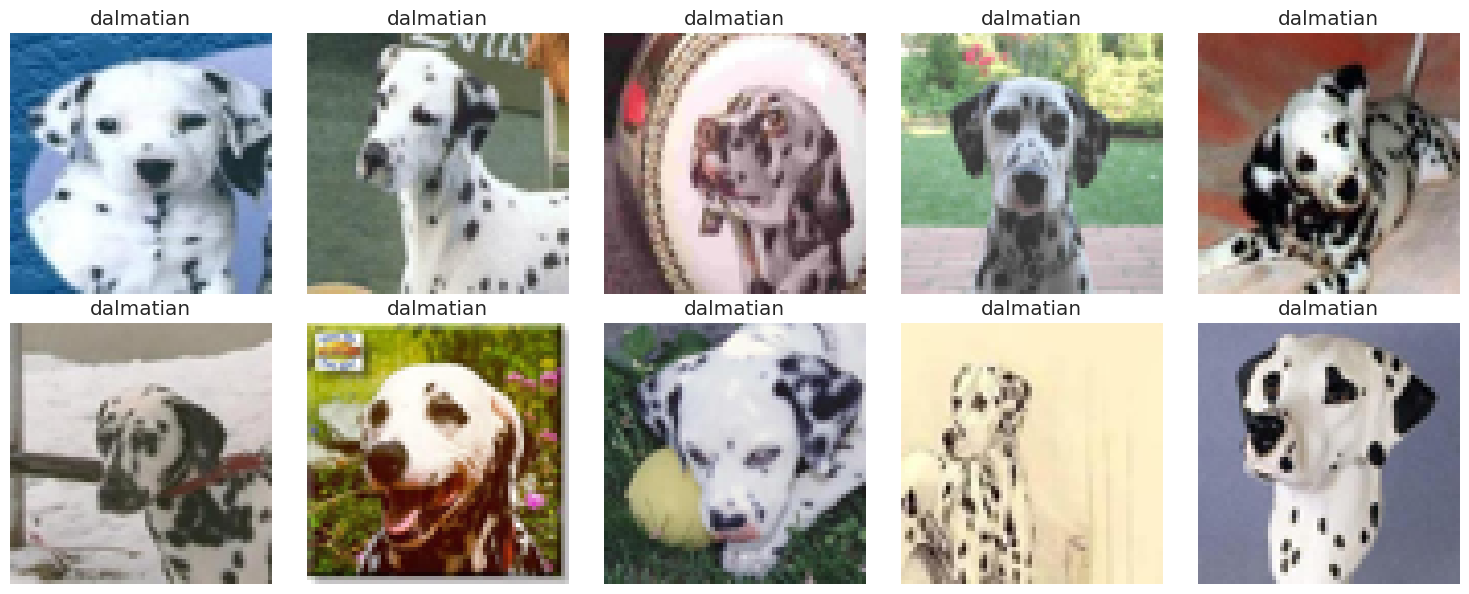

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img = X[i].reshape(64, 64, 3)
    ax.imshow(img)
    ax.set_title(y[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6) Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (247, 12288)
Testing shape: (62, 12288)


## 7) Random Forest + Grid Search

In [9]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score:
0.7410128318150652


## 8) Best Model

In [10]:
best_rf = grid_search.best_estimator_
print(best_rf)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=5, random_state=42)


## 9) Predictions

In [11]:
y_pred = best_rf.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
['soccer_ball' 'pizza' 'dalmatian' 'dalmatian' 'dalmatian' 'sunflower'
 'dollar_bill' 'soccer_ball' 'sunflower' 'sunflower']


## 10) Evaluation Metrics

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8064516129032258
Precision: 0.8045557441992075
Recall: 0.8064516129032258
F1-score: 0.8028938679661703


## 11) Classification Report

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   dalmatian       0.73      0.79      0.76        14
 dollar_bill       0.90      0.90      0.90        10
       pizza       0.75      0.60      0.67        10
 soccer_ball       0.80      0.73      0.76        11
   sunflower       0.84      0.94      0.89        17

    accuracy                           0.81        62
   macro avg       0.81      0.79      0.80        62
weighted avg       0.80      0.81      0.80        62



## 12) Confusion Matrix

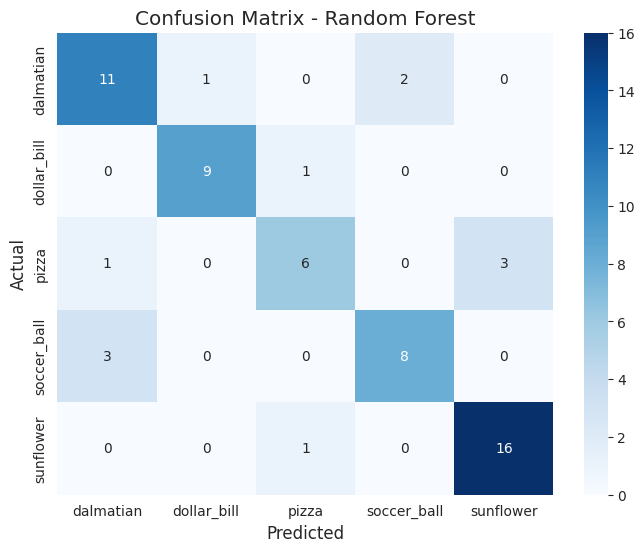

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 13) Feature Importance

In [15]:
importances = best_rf.feature_importances_

print("Feature importances shape:", importances.shape)

Feature importances shape: (12288,)


## 14) Visualize Feature Importance


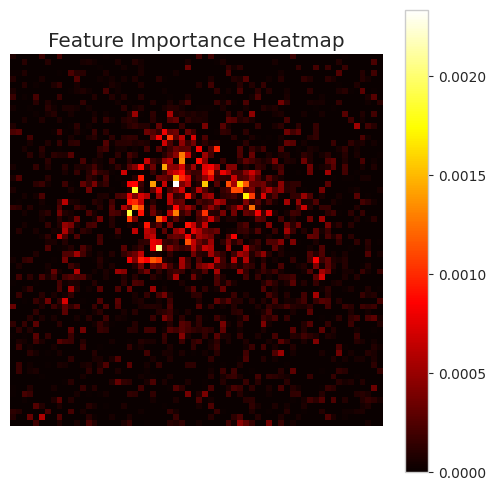

In [16]:
importance_image = importances.reshape(64, 64, 3).mean(axis=2)

plt.figure(figsize=(6, 6))
plt.imshow(importance_image, cmap="hot")
plt.colorbar()
plt.title("Feature Importance Heatmap")
plt.axis("off")
plt.show()

## 15) Predict New Image Function

In [17]:
def predict_new_image(image_path, model, img_size=(64, 64)):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(img_size)
    img_array = np.array(img) / 255.0
    img_flat = img_array.flatten().reshape(1, -1)

    prediction = model.predict(img_flat)[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicted Class: {prediction}")
    plt.axis("off")
    plt.show()

    return prediction

## 16) Test on New Image


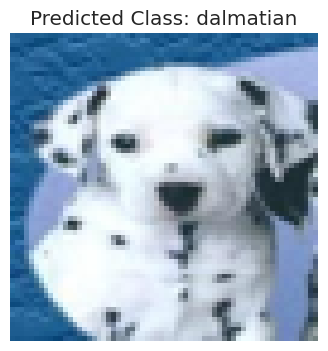

Prediction: dalmatian


In [18]:
sample_image = os.path.join(data_dir, classes[0], os.listdir(os.path.join(data_dir, classes[0]))[0])
pred = predict_new_image(sample_image, best_rf)
print("Prediction:", pred)

## 17) Bonus: SVM

In [19]:
svm_model = SVC(kernel="rbf")
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average="weighted")
svm_recall = recall_score(y_test, svm_pred, average="weighted")
svm_f1 = f1_score(y_test, svm_pred, average="weighted")

print("SVM Accuracy:", svm_accuracy)
print("SVM Precision:", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1-score:", svm_f1)

SVM Accuracy: 0.7903225806451613
SVM Precision: 0.7995478983382209
SVM Recall: 0.7903225806451613
SVM F1-score: 0.7922400180464696


## 18) Compare RF vs SVM

           Model  Accuracy  Precision    Recall  F1-score
0  Random Forest  0.806452   0.804556  0.806452  0.802894
1            SVM  0.790323   0.799548  0.790323  0.792240


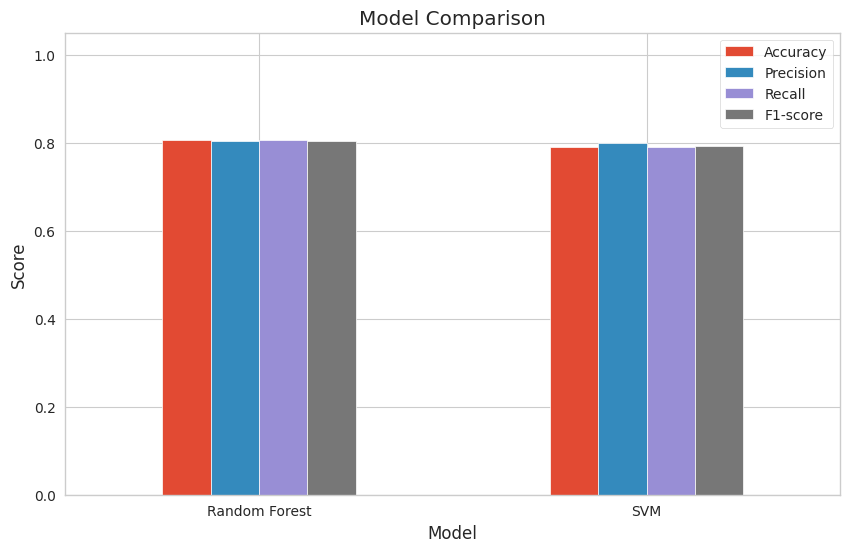

In [20]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Accuracy": [accuracy, svm_accuracy],
    "Precision": [precision, svm_precision],
    "Recall": [recall, svm_recall],
    "F1-score": [f1, svm_f1]
})

print(comparison_df)
comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

19) Markdown for Deployment

# Deployment and Monitoring

The best-performing model can be deployed as a web API using Flask or FastAPI.
Users can upload an image and receive the predicted class.

Potential deployment challenges include:
- image preprocessing consistency
- latency for real-time prediction
- handling many requests at once
- performance degradation on new image types

Monitoring strategies include:
- tracking prediction accuracy on new labeled images
- logging prediction results
- monitoring class distribution
- retraining the model periodically with fresh data

20) Conclusion

# Conclusion

This project demonstrated image classification using a real image dataset containing five categories:
dalmatian, dollar_bill, pizza, soccer_ball, and sunflower.

The images were resized, normalized, and flattened before training.
A Random Forest classifier was trained using GridSearchCV to select the best hyperparameters.
The model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, and classification report.
Feature importance was visualized, and predictions were tested on new images.
As a bonus, an SVM classifier was also trained and compared with the Random Forest model.